In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model saving
import joblib

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# ==============================
#    LOAD DATASET
# ==============================

df = pd.read_csv("../data/processed/flights_cleaned.csv")

print("Dataset shape:", df.shape)

df.head()

C:\Users\shini\AppData\Local\Temp\ipykernel_10988\1342805414.py:5: DtypeWarning: Columns (6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/flights_cleaned.csv")


Dataset shape: (5729194, 14)


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_DELAY,SCHEDULED_TIME,DISTANCE,SCHEDULED_ARRIVAL,DIVERTED
0,2015,1,1,4,AS,98,ANC,SEA,5,-11.0,205.0,1448,430,0
1,2015,1,1,4,AA,2336,LAX,PBI,10,-8.0,280.0,2330,750,0
2,2015,1,1,4,US,840,SFO,CLT,20,-2.0,286.0,2296,806,0
3,2015,1,1,4,AA,258,LAX,MIA,20,-5.0,285.0,2342,805,0
4,2015,1,1,4,AS,135,SEA,ANC,25,-1.0,235.0,1448,320,0


In [3]:
# ==============================
#   BASIC DATA UNDERSTANDING
# ==============================

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_DELAY', 'SCHEDULED_TIME', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DIVERTED']

Data types:
YEAR                     int64
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
AIRLINE                 object
FLIGHT_NUMBER            int64
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
DEPARTURE_DELAY        float64
SCHEDULED_TIME         float64
DISTANCE                 int64
SCHEDULED_ARRIVAL        int64
DIVERTED                 int64
dtype: object

Missing values:
YEAR                   0
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
AIRLINE                0
FLIGHT_NUMBER          0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
DEPARTURE_DELAY        0
SCHEDULED_TIME         0
DISTANCE               0

In [4]:
# ==============================
#      CREATE TARGET
# ==============================

# If departure delay is greater than 0,
# classify the flight as delayed.
#
# Otherwise classify it as on-time.

df["DELAYED"] = (
    df["DEPARTURE_DELAY"] > 0
).astype(int)

print("Target distribution:")
print(df["DELAYED"].value_counts())

print("\nTarget percentage:")
print(
    df["DELAYED"]
    .value_counts(normalize=True)
    * 100
)

Target distribution:
DELAYED
0    3606117
1    2123077
Name: count, dtype: int64

Target percentage:
DELAYED
0    62.942833
1    37.057167
Name: proportion, dtype: float64


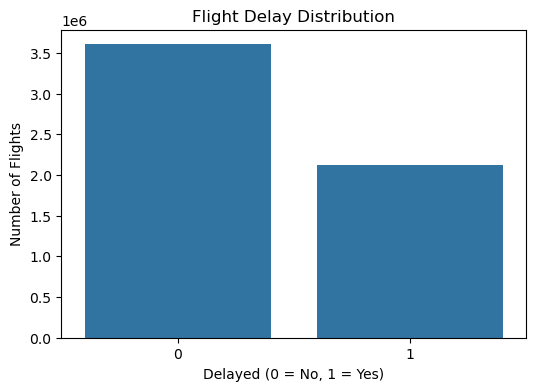

In [5]:
# ==============================
#  TARGET DISTRIBUTION
# ==============================

plt.figure(figsize=(6, 4))

sns.countplot(
    x="DELAYED",
    data=df
)

plt.title("Flight Delay Distribution")
plt.xlabel("Delayed (0 = No, 1 = Yes)")
plt.ylabel("Number of Flights")

plt.show()

In [6]:
# ==============================
#   REMOVE TARGET LEAKAGE
# ==============================

# DEPARTURE_DELAY is used to create DELAYED.
# Therefore it must not be used as an input feature.

df_model = df.drop(
    columns=["DEPARTURE_DELAY"]
)

print("Shape after removing leakage:")
print(df_model.shape)

Shape after removing leakage:
(5729194, 14)


In [7]:
# ==============================
#  TIME FEATURE ENGINEERING
# ==============================

# Convert scheduled departure time
# from HHMM format into hour and minute.

df_model["DEP_HOUR"] = (
    df_model["SCHEDULED_DEPARTURE"] // 100
)

df_model["DEP_MINUTE"] = (
    df_model["SCHEDULED_DEPARTURE"] % 100
)

# Convert scheduled arrival time
# from HHMM format into hour and minute.

df_model["ARR_HOUR"] = (
    df_model["SCHEDULED_ARRIVAL"] // 100
)

df_model["ARR_MINUTE"] = (
    df_model["SCHEDULED_ARRIVAL"] % 100
)

# Convert 24-hour value to 0
df_model["ARR_HOUR"] = (
    df_model["ARR_HOUR"].replace(24, 0)
)

print(
    df_model[
        [
            "SCHEDULED_DEPARTURE",
            "DEP_HOUR",
            "DEP_MINUTE",
            "SCHEDULED_ARRIVAL",
            "ARR_HOUR",
            "ARR_MINUTE"
        ]
    ].head()
)

   SCHEDULED_DEPARTURE  DEP_HOUR  DEP_MINUTE  SCHEDULED_ARRIVAL  ARR_HOUR  \
0                    5         0           5                430         4   
1                   10         0          10                750         7   
2                   20         0          20                806         8   
3                   20         0          20                805         8   
4                   25         0          25                320         3   

   ARR_MINUTE  
0          30  
1          50  
2           6  
3           5  
4          20  


In [8]:
# ==============================
#   CYCLICAL TIME FEATURES
# ==============================

# Departure hour
df_model["DEP_HOUR_SIN"] = np.sin(
    2 * np.pi * df_model["DEP_HOUR"] / 24
)

df_model["DEP_HOUR_COS"] = np.cos(
    2 * np.pi * df_model["DEP_HOUR"] / 24
)

# Arrival hour
df_model["ARR_HOUR_SIN"] = np.sin(
    2 * np.pi * df_model["ARR_HOUR"] / 24
)

df_model["ARR_HOUR_COS"] = np.cos(
    2 * np.pi * df_model["ARR_HOUR"] / 24
)

print(
    df_model[
        [
            "DEP_HOUR",
            "DEP_HOUR_SIN",
            "DEP_HOUR_COS",
            "ARR_HOUR",
            "ARR_HOUR_SIN",
            "ARR_HOUR_COS"
        ]
    ].head()
)

   DEP_HOUR  DEP_HOUR_SIN  DEP_HOUR_COS  ARR_HOUR  ARR_HOUR_SIN  ARR_HOUR_COS
0         0           0.0           1.0         4      0.866025      0.500000
1         0           0.0           1.0         7      0.965926     -0.258819
2         0           0.0           1.0         8      0.866025     -0.500000
3         0           0.0           1.0         8      0.866025     -0.500000
4         0           0.0           1.0         3      0.707107      0.707107


In [9]:
# ==============================
#    CREATE ROUTE FEATURE
# ==============================

df_model["ROUTE"] = (
    df_model["ORIGIN_AIRPORT"].astype(str)
    + "_"
    + df_model["DESTINATION_AIRPORT"].astype(str)
)

print(df_model["ROUTE"].head())

0    ANC_SEA
1    LAX_PBI
2    SFO_CLT
3    LAX_MIA
4    SEA_ANC
Name: ROUTE, dtype: object


In [10]:
# ==============================
#   FEATURES AND TARGET
# ==============================

target = "DELAYED"

feature_columns = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_TIME",
    "DISTANCE",
    "DEP_HOUR",
    "DEP_MINUTE",
    "ARR_HOUR",
    "ARR_MINUTE",
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",
    "ARR_HOUR_SIN",
    "ARR_HOUR_COS",
    "ROUTE"
]

X = df_model[feature_columns]

y = df_model[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (5729194, 17)
Target shape: (5729194,)


In [11]:
# ==============================
#   TRAIN TEST SPLIT
# ==============================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training samples: 4583355
Testing samples : 1145839

Training target distribution:
DELAYED
0    0.629428
1    0.370572
Name: proportion, dtype: float64

Testing target distribution:
DELAYED
0    0.629429
1    0.370571
Name: proportion, dtype: float64


In [12]:
# ==============================
#     FEATURE TYPES
# ==============================

categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "ROUTE"
]

numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_TIME",
    "DISTANCE",
    "DEP_HOUR",
    "DEP_MINUTE",
    "ARR_HOUR",
    "ARR_MINUTE",
    "DEP_HOUR_SIN",
    "DEP_HOUR_COS",
    "ARR_HOUR_SIN",
    "ARR_HOUR_COS"
]

print("Categorical features:")
print(categorical_features)

print("\nNumeric features:")
print(numeric_features)

Categorical features:
['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'ROUTE']

Numeric features:
['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_TIME', 'DISTANCE', 'DEP_HOUR', 'DEP_MINUTE', 'ARR_HOUR', 'ARR_MINUTE', 'DEP_HOUR_SIN', 'DEP_HOUR_COS', 'ARR_HOUR_SIN', 'ARR_HOUR_COS']


In [13]:
# ==============================
#     PREPROCESSING
# ==============================

# Make sure all categorical columns contain strings
for column in categorical_features:
    X_train[column] = X_train[column].astype(str)
    X_test[column] = X_test[column].astype(str)

# Numerical preprocessing
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

# Categorical preprocessing
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

# Combine numerical and categorical pipelines
preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_features
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [14]:
# ==============================
#    TRANSFORM DATA
# ==============================

# Learn preprocessing rules from training data
X_train_processed = (
    preprocessor.fit_transform(X_train)
)

# Apply the same rules to test data
X_test_processed = (
    preprocessor.transform(X_test)
)

print(
    "Processed training shape:",
    X_train_processed.shape
)

print(
    "Processed testing shape:",
    X_test_processed.shape
)

Processed training shape: (4583355, 9858)
Processed testing shape: (1145839, 9858)


In [15]:
# ==============================
#   CLASSIFICATION MODELS
# ==============================

models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            solver="saga"
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=20,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            max_depth=20,
            n_jobs=-1,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            n_estimators=100,
            max_depth=5,
            random_state=42
        )
}

print("Models to be trained:")
for name in models:
    print("-", name)

Models to be trained:
- Logistic Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [16]:
# ==============================
#    TRAIN ALL MODELS
# ==============================

results = []

trained_models = {}

for model_name, model in models.items():

    print("\n" + "=" * 60)
    print("Training:", model_name)
    print("=" * 60)

    # Train
    model.fit(
        X_train_processed,
        y_train
    )

    # Predict class
    predictions = model.predict(
        X_test_processed
    )

    # Predict probability of delay
    probabilities = model.predict_proba(
        X_test_processed
    )[:, 1]

    # Calculate metrics
    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        probabilities
    )

    # Store results
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc
    })

    # Store trained model
    trained_models[model_name] = model

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))


Training: Logistic Regression


C:\Users\shini\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Accuracy : 0.6591
Precision: 0.5813
Recall   : 0.2864
F1 Score : 0.3837
ROC-AUC  : 0.6614

Training: Decision Tree
Accuracy : 0.6845
Precision: 0.6198
Recall   : 0.3847
F1 Score : 0.4747
ROC-AUC  : 0.6898

Training: Random Forest
Accuracy : 0.6325
Precision: 0.8255
Recall   : 0.0107
F1 Score : 0.0211
ROC-AUC  : 0.6715

Training: Gradient Boosting
Accuracy : 0.6784
Precision: 0.6307
Recall   : 0.3185
F1 Score : 0.4233
ROC-AUC  : 0.6972


In [17]:
# ==============================
#    MODEL COMPARISON
# ==============================
 
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1",
    ascending=False
)

results_df.reset_index(
    drop=True,
    inplace=True
)

results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.684543,0.619819,0.384680,0.474728,0.689750
1,Gradient Boosting,0.678351,0.630710,0.318512,0.423270,0.697213
2,Logistic Regression,0.659118,0.581317,0.286370,0.383714,0.661356
3,Random Forest,0.632547,0.825469,0.010671,0.021069,0.671475


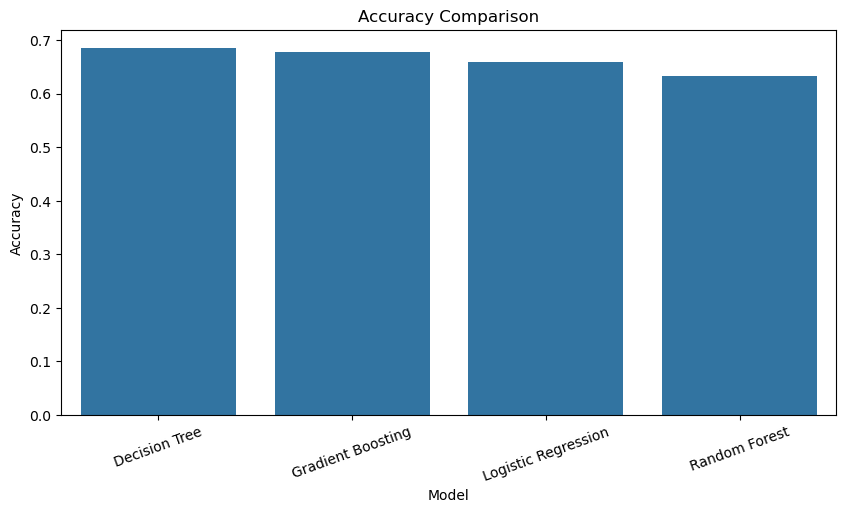

In [18]:
# ==============================
#    ACCURACY COMPARISON
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

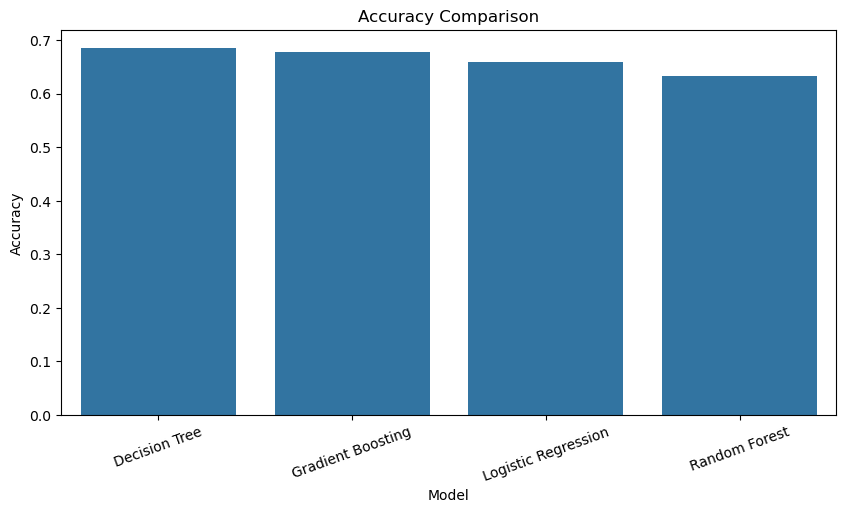

In [19]:
# ==============================
#    ACCURACY COMPARISON
# ==============================

plt.figure(figsize=(10, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy"
)

plt.title("Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=20)

plt.show()

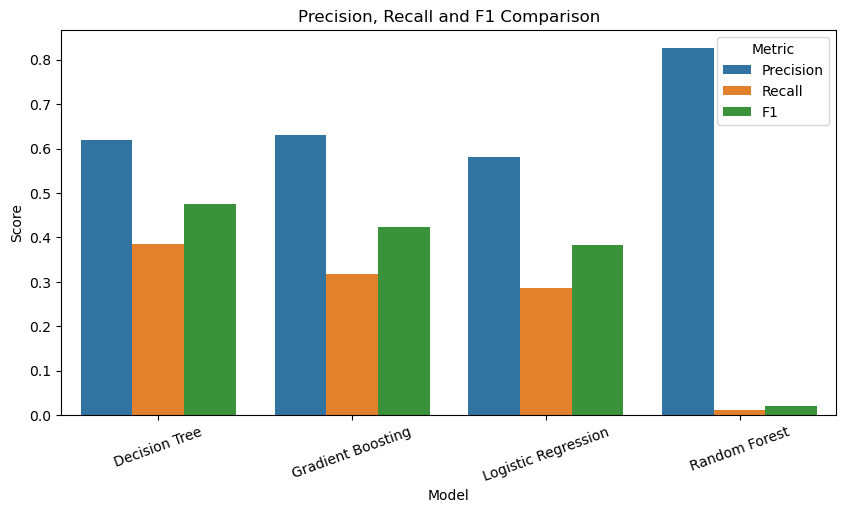

In [20]:
# ==============================
#    PRECISION RECALL F1
# ==============================

metrics_to_plot = [
    "Precision",
    "Recall",
    "F1"
]

plot_data = results_df[
    ["Model"] + metrics_to_plot
].melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=plot_data,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title(
    "Precision, Recall and F1 Comparison"
)

plt.xticks(rotation=20)

plt.show()

In [21]:
# ==============================
#    CLASSIFICATION REPORTS
# ==============================

for model_name, model in trained_models.items():

    predictions = model.predict(
        X_test_processed
    )

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "On-Time",
                "Delayed"
            ],
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

     On-Time       0.68      0.88      0.76    721224
     Delayed       0.58      0.29      0.38    424615

    accuracy                           0.66   1145839
   macro avg       0.63      0.58      0.57   1145839
weighted avg       0.64      0.66      0.62   1145839



Decision Tree
              precision    recall  f1-score   support

     On-Time       0.70      0.86      0.77    721224
     Delayed       0.62      0.38      0.47    424615

    accuracy                           0.68   1145839
   macro avg       0.66      0.62      0.62   1145839
weighted avg       0.67      0.68      0.66   1145839



Random Forest
              precision    recall  f1-score   support

     On-Time       0.63      1.00      0.77    721224
     Delayed       0.83      0.01      0.02    424615

    accuracy                           0.63   1145839
   macro avg       0.73      0.50      0.40   1145839
weighted avg       0

In [22]:
# ==============================
#    CLASSIFICATION REPORTS
# ==============================

for model_name, model in trained_models.items():

    predictions = model.predict(
        X_test_processed
    )

    print("\n")
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=[
                "On-Time",
                "Delayed"
            ],
            zero_division=0
        )
    )



Logistic Regression
              precision    recall  f1-score   support

     On-Time       0.68      0.88      0.76    721224
     Delayed       0.58      0.29      0.38    424615

    accuracy                           0.66   1145839
   macro avg       0.63      0.58      0.57   1145839
weighted avg       0.64      0.66      0.62   1145839



Decision Tree
              precision    recall  f1-score   support

     On-Time       0.70      0.86      0.77    721224
     Delayed       0.62      0.38      0.47    424615

    accuracy                           0.68   1145839
   macro avg       0.66      0.62      0.62   1145839
weighted avg       0.67      0.68      0.66   1145839



Random Forest
              precision    recall  f1-score   support

     On-Time       0.63      1.00      0.77    721224
     Delayed       0.83      0.01      0.02    424615

    accuracy                           0.63   1145839
   macro avg       0.73      0.50      0.40   1145839
weighted avg       0

In [23]:
# ==============================
#     SELECT BEST MODEL
# ==============================

best_model_name = results_df.iloc[0]["Model"]

best_model = trained_models[
    best_model_name
]

print(
    "Selected model:",
    best_model_name
)

print("\nPerformance:")
print(
    results_df.iloc[0]
)

Selected model: Decision Tree

Performance:
Model        Decision Tree
Accuracy          0.684543
Precision         0.619819
Recall             0.38468
F1                0.474728
ROC-AUC            0.68975
Name: 0, dtype: object


In [25]:
# ==============================
#    FINAL MODEL EVALUATION
# ==============================

final_predictions = best_model.predict(
    X_test_processed
)

final_probabilities = best_model.predict_proba(
    X_test_processed
)[:, 1]

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "On-Time",
            "Delayed"
        ],
        zero_division=0
    )
)

print(
    "Final Accuracy:",
    round(
        accuracy_score(
            y_test,
            final_predictions
        ),
        4
    )
)

print(
    "Final ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            final_probabilities
        ),
        4
    )
)

              precision    recall  f1-score   support

     On-Time       0.70      0.86      0.77    721224
     Delayed       0.62      0.38      0.47    424615

    accuracy                           0.68   1145839
   macro avg       0.66      0.62      0.62   1145839
weighted avg       0.67      0.68      0.66   1145839

Final Accuracy: 0.6845
Final ROC-AUC: 0.6898


In [26]:
# ==============================
#    SAVE BEST MODEL
# ==============================

model_package = {

    "preprocessor": preprocessor,

    "model": best_model,

    "features": feature_columns,

    "model_name": best_model_name,

    "categorical_features":
        categorical_features,

    "numeric_features":
        numeric_features
}

joblib.dump(
    model_package,
    "../models/classification_model.joblib"
)

print(
    "Classification model saved successfully!"
)

print(
    "Model:",
    best_model_name
)

Classification model saved successfully!
Model: Decision Tree


In [27]:
# ==============================
#    FINAL MODEL EVALUATION
# ==============================

final_predictions = best_model.predict(
    X_test_processed
)

final_probabilities = best_model.predict_proba(
    X_test_processed
)[:, 1]

print(
    classification_report(
        y_test,
        final_predictions,
        target_names=[
            "On-Time",
            "Delayed"
        ],
        zero_division=0
    )
)

print(
    "Final Accuracy:",
    round(
        accuracy_score(
            y_test,
            final_predictions
        ),
        4
    )
)

print(
    "Final ROC-AUC:",
    round(
        roc_auc_score(
            y_test,
            final_probabilities
        ),
        4
    )
)

              precision    recall  f1-score   support

     On-Time       0.70      0.86      0.77    721224
     Delayed       0.62      0.38      0.47    424615

    accuracy                           0.68   1145839
   macro avg       0.66      0.62      0.62   1145839
weighted avg       0.67      0.68      0.66   1145839

Final Accuracy: 0.6845
Final ROC-AUC: 0.6898


In [37]:
# ==============================
#     TEST ONE PREDICTION
# ==============================

# Take one sample from test dataset
sample = X_test.iloc[[6]]

# Actual result
actual = y_test.iloc[2]

# Preprocess sample
sample_processed = (
    preprocessor.transform(
        sample
    )
)

# Prediction
prediction = model.predict(
    sample_processed
)[0]

# Probability
delay_probability = (
    model.predict_proba(
        sample_processed
    )[0][1]
)

print("Actual value:", actual)

print(
    "Predicted value:",
    prediction
)

print(
    "Delay probability:",
    round(
        delay_probability * 100,
        2
    ),
    "%"
)

Actual value: 0
Predicted value: 0
Delay probability: 31.9 %


In [38]:
# ==============================
#    FINAL PREDICTION
# ==============================

if prediction == 1:

    print(
        " Prediction: FLIGHT IS LIKELY TO BE DELAYED"
    )

else:

    print(
        " Prediction: FLIGHT IS LIKELY TO BE ON-TIME"
    )

print(
    f"Probability of delay: "
    f"{delay_probability:.2%}"
)

 Prediction: FLIGHT IS LIKELY TO BE ON-TIME
Probability of delay: 31.90%
